# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Joyceline Octavia Lumban Tobing
- **Email:** cdcc319d6x0973@student.devacademy.id
- **ID Dicoding:** CDCC319D6X0973

## Menentukan Pertanyaan Bisnis

- Kategori produk apa yang memberikan kontribusi terbesar terhadap total penjualan, dan bagaimana distribusi penjualan antar kategori?
- Bagaimana tren jumlah pesanan dari waktu ke waktu, dan apakah terdapat pola tertentu dalam periode penjualan?

## Import Semua Packages/Library yang Digunakan

In [62]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

sns.set(style='whitegrid')

## Data Wrangling

### Gathering Data

In [63]:
# Load tabel orders_df
orders_df = pd.read_csv('data/orders_dataset.csv')
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [64]:
# Load tabel order_items_df
order_items_df = pd.read_csv('data/order_items_dataset.csv')
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [65]:
# Load tabel reviews_df
reviews_df = pd.read_csv('data/order_reviews_dataset.csv')
reviews_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [66]:
# Load tabel products_df
products_df = pd.read_csv('data/products_dataset.csv')
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


**Insight:**
- Data terdiri dari beberapa tabel yang saling terhubung melalui order_id dan product_id, sehingga memungkinkan penggabungan data untuk analisis yang lebih menyeluruh.
- Tabel order_items menunjukkan bahwa satu pesanan dapat berisi lebih dari satu produk, serta menyediakan informasi harga dan biaya pengiriman yang dapat digunakan untuk menghitung total penjualan.
- Tabel order_reviews mengindikasikan bahwa tidak semua pelanggan memberikan ulasan dalam bentuk teks, karena masih terdapat nilai kosong pada kolom komentar.

### Assessing Data

In [67]:
# Menilai data orders_df
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [68]:
orders_df.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [69]:
print("Jumlah duplikasi: ", orders_df.duplicated().sum())
orders_df.describe()

Jumlah duplikasi:  0


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:05:26,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 19:36:48,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [70]:
# Menilai data order_items_df
order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [71]:
print("Jumlah duplikasi: ", order_items_df.duplicated().sum())
order_items_df.describe()

Jumlah duplikasi:  0


,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [72]:
# Menilai data order reviews_df
reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [73]:
reviews_df.isna().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [74]:
print("Jumlah duplikasi: ", reviews_df.duplicated().sum())
reviews_df.describe()

Jumlah duplikasi:  0


,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [75]:
# Menilai data products_df
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [76]:
products_df.isna().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [77]:
print("Jumlah duplikasi: ", products_df.duplicated().sum())
products_df.describe()

Jumlah duplikasi:  0


,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


**Insight:**
- Tipe data: Beberapa kolom tanggal pada orders_df, order_items_df, dan reviews_df masih bertipe objek, sehingga perlu dikonversi ke datetime.
- Missing value: Terdapat missing value pada orders_df, reviews_df, dan products_df, dengan jumlah paling banyak pada kolom komentar di reviews_df.
- Duplicate: Tidak ditemukan data duplikasi pada seluruh tabel.
- Inaccurate value: Terdapat nilai tidak wajar pada products_df, yaitu produk dengan berat 0 gram.

### Cleaning Data

In [78]:
# Cleaning tabel orders_df
datetime_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for column in datetime_columns:
    orders_df[column] = pd.to_datetime(orders_df[column])

In [79]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [80]:
# Memilih data yang valid untuk dianalisis di tabel orders_df
orders_df = orders_df[orders_df['order_status'] == 'delivered']

In [81]:
# Drop data yang tidak valid
orders_df = orders_df.dropna()

In [82]:
# Cleaning tabel order_items_df
order_items_df['shipping_limit_date'] = pd.to_datetime(order_items_df['shipping_limit_date'])

In [83]:
order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


In [84]:
# Cleaning tabel reviews_df
datetime_columns = [
    'review_creation_date',
    'review_answer_timestamp'
]

for column in datetime_columns:
    reviews_df[column] = pd.to_datetime(reviews_df[column])

In [85]:
reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  object        
 1   order_id                 99224 non-null  object        
 2   review_score             99224 non-null  int64         
 3   review_comment_title     11568 non-null  object        
 4   review_comment_message   40977 non-null  object        
 5   review_creation_date     99224 non-null  datetime64[ns]
 6   review_answer_timestamp  99224 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 5.3+ MB


In [86]:
# Menghapus missing value pada kolom product_category_name di tabel products_df
products_df = products_df.dropna(subset=['product_category_name'])

In [87]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32341 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32341 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32340 non-null  float64
 6   product_length_cm           32340 non-null  float64
 7   product_height_cm           32340 non-null  float64
 8   product_width_cm            32340 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.5+ MB


In [88]:
products_df.isna().sum()

product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              1
product_length_cm             1
product_height_cm             1
product_width_cm              1
dtype: int64

In [89]:
# Menghapus missing value pada atribut dimensi dan berat produk
products_df = products_df.dropna(subset=[
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
])

In [90]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32340 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32340 non-null  object 
 1   product_category_name       32340 non-null  object 
 2   product_name_lenght         32340 non-null  float64
 3   product_description_lenght  32340 non-null  float64
 4   product_photos_qty          32340 non-null  float64
 5   product_weight_g            32340 non-null  float64
 6   product_length_cm           32340 non-null  float64
 7   product_height_cm           32340 non-null  float64
 8   product_width_cm            32340 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.5+ MB


In [91]:
# Menangani inaccurate value 
products_df[products_df['product_weight_g'] == products_df['product_weight_g'].min()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
9769,81781c0fed9fe1ad6e8c81fca1e1cb08,cama_mesa_banho,51.0,529.0,1.0,0.0,30.0,25.0,30.0
13683,8038040ee2a71048d4bdbbdc985b69ab,cama_mesa_banho,48.0,528.0,1.0,0.0,30.0,25.0,30.0
14997,36ba42dd187055e1fbe943b2d11430ca,cama_mesa_banho,53.0,528.0,1.0,0.0,30.0,25.0,30.0
32079,e673e90efa65a5409ff4196c038bb5af,cama_mesa_banho,53.0,528.0,1.0,0.0,30.0,25.0,30.0


In [92]:
# Drop karena ada kesalahan input data dan jumlahnya terlampau sedikit
products_df = products_df[products_df['product_weight_g'] != 0]

In [93]:
products_df[products_df['product_weight_g'] == products_df['product_weight_g'].min()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
9396,ad7d07f5775feab3f20504d1ad3fff11,moveis_decoracao,50.0,1002.0,2.0,2.0,11.0,11.0,52.0
13397,7ddb76f2c7237acc852358b95e7946a8,papelaria,49.0,1048.0,2.0,2.0,11.0,11.0,52.0
15374,f9fafac43d3416d92ecc303fdeb1743d,moveis_decoracao,51.0,1039.0,2.0,2.0,11.0,11.0,52.0
15675,8aae4df46baf1278422b69edbb50bd35,moveis_decoracao,56.0,1002.0,2.0,2.0,11.0,11.0,52.0
16181,5837bba0ce6e35e6f2dc5c3e223e3276,moveis_decoracao,52.0,1041.0,2.0,2.0,11.0,11.0,52.0


**Insight:**
- orders_df: Tipe data pada seluruh kolom waktu telah dikonversi menjadi datetime, dan missing value tidak langsung dihapus, melainkan ditangani dengan melakukan filtering pada data dengan status pesanan delivered, sehingga hanya data yang relevan dan valid yang digunakan dalam analisis.
- order_items_df: Kolom waktu pada tabel order_items_df telah dikonversi menjadi tipe datetime untuk memudahkan analisis berbasis waktu. 
- reviews_df: Tipe data pada kolom waktu telah dikonversi menjadi datetime. Terdapat missing value dalam jumlah besar pada kolom komentar, mencapai puluhan ribu data. Namun, data tidak dihapus karena kolom tersebut bersifat opsional dan tidak memengaruhi analisis utama yang berfokus pada nilai review_score.
- products_df: Missing value ditangani secara selektif menggunakan parameter subset, yaitu hanya pada kolom yang penting seperti kategori produk. Selain itu, ditemukan nilai yang tidak akurat berupa berat produk bernilai 0, sehingga data tersebut dihapus karena tidak sesuai secara logika dan berpotensi memengaruhi hasil analisis.

## Exploratory Data Analysis (EDA)

### Explore ...

In [94]:
# Eksplorasi data orders_df

# Membuat kolom baru "delivery time" untuk mengetahu lama pengantaran
delivery_time = orders_df["order_delivered_customer_date"] - orders_df["order_purchase_timestamp"]
delivery_time = delivery_time.dt.total_seconds()

orders_df["delivery_time_days"] = round(delivery_time / 86400)

In [95]:
orders_df.describe(include="all")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days
count,96455,96455,96455,96455,96455,96455,96455,96455,96455.000000
unique,96455,96455,1,NaN,NaN,NaN,NaN,NaN,NaN
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,1,96455,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,2018-01-02 00:26:23.673806336,2018-01-02 10:43:03.401710592,2018-01-05 05:53:41.200134656,2018-01-14 13:49:28.328526336,2018-01-25 18:04:03.421284864,12.516510
min,NaN,NaN,NaN,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-10-04 00:00:00,1.000000
25%,NaN,NaN,NaN,2017-09-14 09:39:02.500000,2017-09-14 14:42:23,2017-09-18 17:06:18.500000,2017-09-25 22:56:47,2017-10-05 00:00:00,7.000000
50%,NaN,NaN,NaN,2018-01-20 20:00:12,2018-01-22 13:49:24,2018-01-24 16:28:58,2018-02-02 19:52:30,2018-02-16 00:00:00,10.000000
75%,NaN,NaN,NaN,2018-05-05 18:53:33,2018-05-06 10:52:57.500000,2018-05-08 14:34:30,2018-05-15 23:09:15.500000,2018-05-28 00:00:00,16.000000
max,NaN,NaN,NaN,2018-08-29 15:00:37,2018-08-29 15:10:26,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-10-25 00:00:00,210.000000


In [96]:
# Membuat kolom baru "delay" untuk mengetahui pengantaran yang terlambat 
# (delay = 0 berarti tepat waktu, delay < 0 berarti lebih cepat, dan delay > 0 berarti terlambat)
orders_df["delay"] = (
    orders_df["order_delivered_customer_date"] - 
    orders_df["order_estimated_delivery_date"]
).dt.days

orders_df[['order_delivered_customer_date', 'order_estimated_delivery_date', 'delay']].head()

,order_delivered_customer_date,order_estimated_delivery_date,delay
0,2017-10-10 21:25:13,2017-10-18,-8
1,2018-08-07 15:27:45,2018-08-13,-6
2,2018-08-17 18:06:29,2018-09-04,-18
3,2017-12-02 00:28:42,2017-12-15,-13
4,2018-02-16 18:17:02,2018-02-26,-10


In [97]:
# Melihat delay yang dari yang terbesar karena terdapat perbedaan besar antara delay min dan max
orders_df.sort_values(by='delay', ascending=False).head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days,delay
55619,1b3190b2dfa9d789e1f14c05b647a14a,d306426abe5fca15e54b645e4462dc7b,delivered,2018-02-23 14:57:35,2018-02-23 15:16:14,2018-02-26 18:49:07,2018-09-19 23:24:07,2018-03-15,208.0,188
19590,ca07593549f1816d26a572e06dc1eab6,75683a92331068e2d281b11a7866ba44,delivered,2017-02-21 23:31:27,2017-02-23 02:35:15,2017-03-08 13:47:46,2017-09-19 14:36:39,2017-03-22,210.0,181
11399,47b40429ed8cce3aee9199792275433f,cb2caaaead400c97350c37a3fc536867,delivered,2018-01-03 09:44:01,2018-01-03 10:31:15,2018-02-06 01:48:28,2018-07-13 20:51:31,2018-01-19,191.0,175
81401,2fe324febf907e3ea3f2aa9650869fa5,65b14237885b3972ebec28c0f7dd2220,delivered,2017-03-13 20:17:10,2017-03-13 20:17:10,2017-03-17 07:23:53,2017-09-19 17:00:07,2017-04-05,190.0,167
89130,285ab9426d6982034523a855f55a885e,9cf2c3fa2632cee748e1a59ca9d09b21,delivered,2017-03-08 22:47:40,2017-03-08 22:47:40,2017-03-09 08:53:20,2017-09-19 14:00:04,2017-04-06,195.0,166


In [98]:
# Eksplorasi data orders_item_df
order_items_df.describe(include="all")

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
count,112650,112650.000000,112650,112650,112650,112650.000000,112650.000000
unique,98666,NaN,32951,3095,NaN,NaN,NaN
top,8272b63d03f5f79c56e9e4120aec44ef,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,NaN,NaN,NaN
freq,21,NaN,527,2033,NaN,NaN,NaN
mean,NaN,1.197834,NaN,NaN,2018-01-07 15:36:52.192685312,120.653739,19.990320
min,NaN,1.000000,NaN,NaN,2016-09-19 00:15:34,0.850000,0.000000
25%,NaN,1.000000,NaN,NaN,2017-09-20 20:57:27.500000,39.900000,13.080000
50%,NaN,1.000000,NaN,NaN,2018-01-26 13:59:35,74.990000,16.260000
75%,NaN,1.000000,NaN,NaN,2018-05-10 14:34:00.750000128,134.900000,21.150000
max,NaN,21.000000,NaN,NaN,2020-04-09 22:35:08,6735.000000,409.680000


In [99]:
order_items_df.sort_values(by="price", ascending=False)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
3556,0812eb902a67711a1cb742b3cdaa65ae,1,489ae2aa008f021502940f251d4cce7f,e3b4998c7a498169dc7bce44e6bb6277,2017-02-16 20:37:36,6735.00,194.31
112233,fefacc66af859508bf1a7934eab1e97f,1,69c590f7ffc7bf8db97190b6cb6ed62e,80ceebb4ee9b31afb6c6a916a574a1e2,2018-08-02 04:05:13,6729.00,193.21
107841,f5136e38d1a14a4dbd87dff67da82701,1,1bdf5e6731585cf01aa8169c7028d6ad,ee27a8f15b1dded4d213a468ba4eb391,2017-06-15 02:45:17,6499.00,227.66
74336,a96610ab360d42a2e5335a3998b4718a,1,a6492cc69376c469ab6f61d8f44de961,59417c56835dd8e2e72f91f809cd4092,2017-04-18 13:25:18,4799.00,151.34
11249,199af31afc78c699f0dbf71fb178d4d4,1,c3ed642d592594bb648ff4a04cee2747,59417c56835dd8e2e72f91f809cd4092,2017-05-09 15:50:15,4690.00,74.34
...,...,...,...,...,...,...,...
57300,8272b63d03f5f79c56e9e4120aec44ef,4,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89
57307,8272b63d03f5f79c56e9e4120aec44ef,11,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89
48625,6e864b3f0ec71031117ad4cf46b7f2a1,1,8a3254bee785a526d548a81a9bc3c9be,96804ea39d96eb908e7c3afdb671bb9e,2018-05-02 20:30:34,0.85,18.23
27652,3ee6513ae7ea23bdfab5b9ab60bffcb5,1,8a3254bee785a526d548a81a9bc3c9be,96804ea39d96eb908e7c3afdb671bb9e,2018-05-04 03:55:26,0.85,18.23


In [100]:
# Jumlah item per order
order_items_df.groupby('order_id').size().describe()

count    98666.000000
mean         1.141731
std          0.538452
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         21.000000
dtype: float64

In [101]:
# Eksplorasi data products_df

# Distribusi kategori produk
products_df['product_category_name'].value_counts()

product_category_name
cama_mesa_banho                  3025
esporte_lazer                    2867
moveis_decoracao                 2657
beleza_saude                     2444
utilidades_domesticas            2335
                                 ... 
fashion_roupa_infanto_juvenil       5
casa_conforto_2                     5
pc_gamer                            3
seguros_e_servicos                  2
cds_dvds_musicais                   1
Name: count, Length: 73, dtype: int64

In [102]:
# Variasi ukuran produk
products_df[['product_length_cm','product_height_cm','product_width_cm']].describe()

,product_length_cm,product_height_cm,product_width_cm
count,32336.000000,32336.000000,32336.000000
mean,30.854651,16.957818,23.207756
std,16.957011,13.636665,12.079273
min,7.000000,2.000000,6.000000
25%,18.000000,8.000000,15.000000
50%,25.000000,13.000000,20.000000
75%,38.000000,21.000000,30.000000
max,105.000000,105.000000,118.000000


In [103]:
# Merge tabel order_items_df dan products_df
sales_product_df = pd.merge(
    left=order_items_df,
    right=products_df,
    how="left",
    on="product_id"
)

sales_product_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0


In [104]:
# Total penjualan dan jumlah produk yang terjual
sales_product_df.groupby('product_category_name').agg({
    'product_id': 'nunique',
    'price': ['sum', 'min', 'max']
})

product_id      price                
                             nunique        sum    min      max
product_category_name                                          
agro_industria_e_comercio         74   72530.47  12.99  2990.00
alimentos                         82   29393.41   9.99   274.99
alimentos_bebidas                104   15179.48   6.50   699.90
artes                             55   24202.64   3.50  6499.00
artes_e_artesanato                19    1814.01   9.80   289.49
...                              ...        ...    ...      ...
sinalizacao_e_seguranca           93   21509.23   4.50   740.00
tablets_impressao_imagem           9    7528.41  14.90   889.99
telefonia                       1134  323667.53   5.00  2428.00
telefonia_fixa                   116   59583.00   6.00  1790.00
utilidades_domesticas           2335  632248.66   3.06  6735.00

[73 rows x 4 columns]

In [105]:
# Eksplorasi reviews_df

# Distribusi rating
reviews_df['review_score'].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

In [106]:
# Rata-rata rating
reviews_df['review_score'].mean()

np.float64(4.08642062404257)

In [107]:
# Tren review dari waktu ke waktu
reviews_df.groupby(reviews_df['review_creation_date'].dt.to_period('M')).size()

review_creation_date
2016-10     179
2016-11     101
2016-12      45
2017-01     239
2017-02    1413
2017-03    2481
2017-04    2055
2017-05    3710
2017-06    3440
2017-07    3503
2017-08    4503
2017-09    4199
2017-10    4424
2017-11    4786
2017-12    7982
2018-01    6179
2018-02    6101
2018-03    7803
2018-04    7287
2018-05    7458
2018-06    6715
2018-07    5634
2018-08    8987
Freq: M, dtype: int64

In [108]:
# Merge orders_df dan reviews_df
orders_reviews_df = pd.merge(
    orders_df,
    reviews_df,
    on='order_id',
    how='left'
)

orders_reviews_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days,delay,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,-8,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,14.0,-6,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,-18,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18,2018-08-22 19:07:58
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,-13,359d03e676b3c069f62cadba8dd3f6e8,5.0,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03,2017-12-05 19:21:58
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,3.0,-10,e50934924e227544ba8246aeb3770dd4,5.0,NaN,NaN,2018-02-17,2018-02-18 13:02:51


In [109]:
# Analisis apakah 
orders_reviews_df.groupby('review_score')['delay'].mean()

review_score
1.0    -4.048060
2.0    -8.624830
3.0   -10.775754
4.0   -12.378549
5.0   -13.387029
Name: delay, dtype: float64

In [110]:
# Eksplorasi all_df

# Merge tabel sales_product_df dan orders_reviews_df berdasarkan order_id
all_df = pd.merge(
    left=sales_product_df,
    right=orders_reviews_df,
    how="left",
    on="order_id"
)

all_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,...,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days,delay,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,...,2017-09-20 23:43:48,2017-09-29,8.0,-9.0,97ca439bc427b48bc1cd7177abe71365,5.0,NaN,"Perfeito, produto entregue antes do combinado.",2017-09-21,2017-09-22 10:57:03
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,...,2017-05-12 16:04:24,2017-05-15,16.0,-3.0,7b07bacd811c4117b742569b04ce3580,4.0,NaN,NaN,2017-05-13,2017-05-15 11:34:13
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,...,2018-01-22 13:19:16,2018-02-05,8.0,-14.0,0c5b33dea94867d1ac402749e5438e8b,5.0,NaN,Chegou antes do prazo previsto e o produto sur...,2018-01-23,2018-01-23 16:06:31
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,...,2018-08-14 13:32:39,2018-08-20,6.0,-6.0,f4028d019cb58564807486a6aaf33817,4.0,NaN,NaN,2018-08-15,2018-08-15 16:39:01
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,...,2017-03-01 16:42:31,2017-03-17,25.0,-16.0,940144190dcba6351888cafa43f3a3a5,5.0,NaN,Gostei pois veio no prazo determinado .,2017-03-02,2017-03-03 10:54:59


In [111]:
# Menghitung total penjualan dan jumlah item terjual berdasarkan kategori produk
sales_per_category = all_df.groupby('product_category_name').agg({
    'price': 'sum',
    'order_id': 'count'
}).sort_values(by='price', ascending=False)

sales_per_category.head()

,price,order_id
product_category_name,,
beleza_saude,1262989.57,9724
relogios_presentes,1206075.33,6001
cama_mesa_banho,1049782.11,11261
esporte_lazer,993385.51,8699
informatica_acessorios,919472.99,7891


In [112]:
# Menghitung jumlah pesanan per bulan untuk melihat tren waktu
orders_trend = all_df.groupby(
    all_df['order_purchase_timestamp'].dt.to_period('M')
).size()

orders_trend

order_purchase_timestamp
2016-09       3
2016-10     317
2016-12       1
2017-01     922
2017-02    1856
2017-03    2917
2017-04    2577
2017-05    4047
2017-06    3524
2017-07    4460
2017-08    4851
2017-09    4770
2017-10    5256
2017-11    8536
2017-12    6214
2018-01    8088
2018-02    7617
2018-03    8064
2018-04    7838
2018-05    7819
2018-06    7013
2018-07    6982
2018-08    7144
Freq: M, dtype: int64

In [113]:
# Simpan data yang sudah dicleaning dan diexplore
all_df.to_csv("main_data.csv", index=False)

**Insight:**
- Waktu pengiriman memiliki variasi yang cukup besar, dengan keterlambatan terlama mencapai 188 hari. Hal ini menunjukkan adanya beberapa kasus ekstrem dalam proses pengiriman.
- Harga produk sangat beragam, mulai dari 0,85 hingga 6.735. Perbedaan ini mencerminkan bahwa platform menjual berbagai jenis produk dengan rentang harga yang luas.
- Jumlah item dalam satu pesanan relatif kecil, meskipun terdapat beberapa kasus di mana pelanggan membeli hingga 21 item dalam satu transaksi.
- Kategori cama_mesa_banho memiliki jumlah item terjual paling tinggi dibandingkan kategori lainnya, yang menunjukkan bahwa kategori ini paling sering dibeli oleh pelanggan. Namun, kategori dengan jumlah item terjual terbanyak tidak selalu menghasilkan penjualan terbesar. Kategori beleza_saude justru memiliki total penjualan tertinggi, yang mengindikasikan bahwa nilai transaksi pada kategori ini cenderung lebih besar.
- Sebagian besar pelanggan memberikan rating tinggi, dengan rating 5 menjadi yang paling dominan. Hal ini mengindikasikan tingkat kepuasan pelanggan yang cukup baik.
- Rata-rata rating berada di sekitar angka 4, yang menunjukkan bahwa secara umum pengalaman pelanggan terhadap layanan tergolong positif.
- Terdapat hubungan antara kecepatan pengiriman dan kepuasan pelanggan. Pesanan yang dikirim lebih cepat dari estimasi cenderung mendapatkan rating yang lebih tinggi, terlihat dari nilai delay yang semakin negatif pada rating yang lebih tinggi.
- Jumlah pesanan menunjukkan tren meningkat dari waktu ke waktu, terutama sejak tahun 2017 hingga 2018. Meskipun terdapat fluktuasi pada beberapa bulan, secara keseluruhan terjadi pertumbuhan aktivitas transaksi. Lonjakan terlihat pada periode tertentu, seperti akhir tahun, yang mengindikasikan adanya pengaruh musim atau momen tertentu terhadap peningkatan jumlah pesanan.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

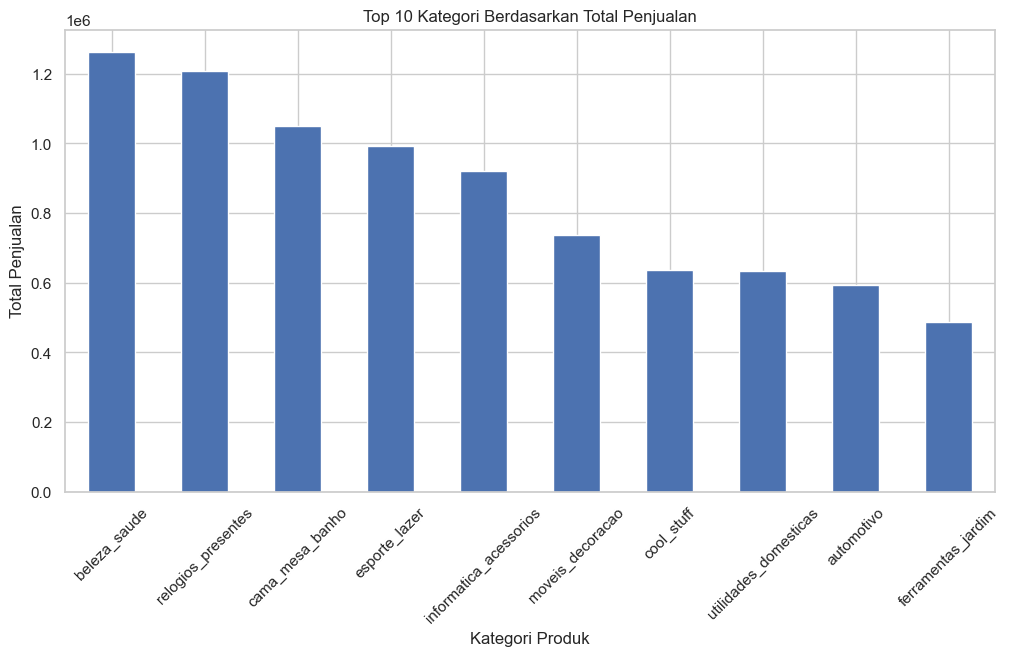

In [114]:
# Menghitung total penjualan per kategori produk
sales_per_category = all_df.groupby('product_category_name')['price'].sum().sort_values(ascending=False)

# Visualisasi: Top 10 kategori berdasarkan total penjualan
plt.figure(figsize=(12, 6))
sales_per_category.head(10).plot(kind='bar')

plt.title("Top 10 Kategori Berdasarkan Total Penjualan")
plt.xlabel("Kategori Produk")
plt.ylabel("Total Penjualan")
plt.xticks(rotation=45)
plt.show()

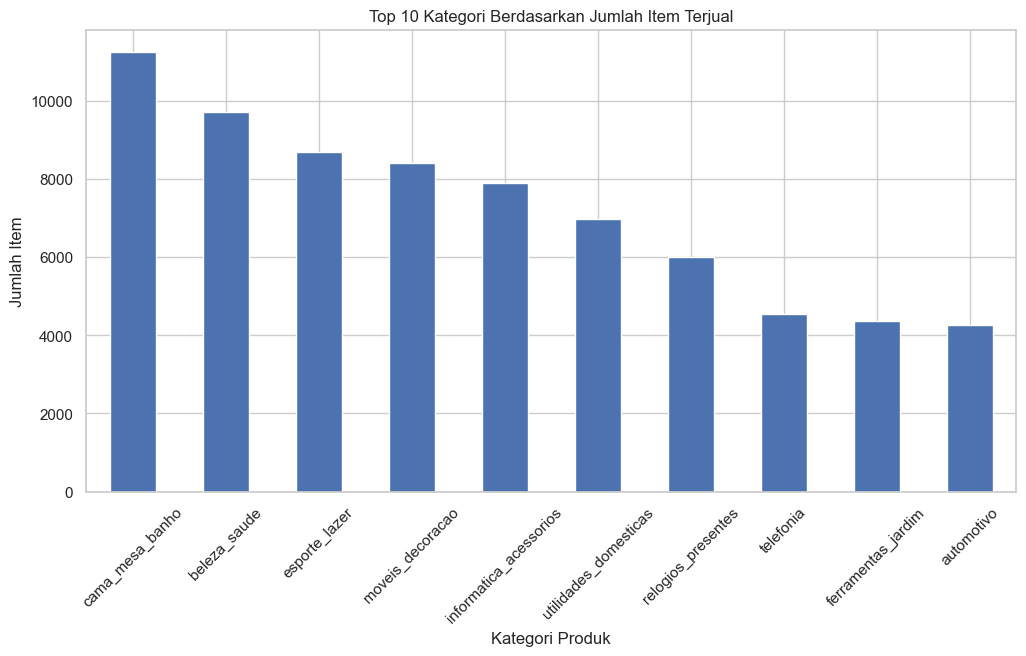

In [115]:
# Menghitung jumlah item terjual per kategori
items_per_category = all_df.groupby('product_category_name').size().sort_values(ascending=False)

# Visualisasi: Top 10 kategori berdasarkan jumlah item terjual
plt.figure(figsize=(12, 6))
items_per_category.head(10).plot(kind='bar')

plt.title("Top 10 Kategori Berdasarkan Jumlah Item Terjual")
plt.xlabel("Kategori Produk")
plt.ylabel("Jumlah Item")
plt.xticks(rotation=45)
plt.show()

### Pertanyaan 2:

C:\Users\joyce\AppData\Local\Temp\ipykernel_8092\4211216397.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_orders = all_df.resample(rule='M', on='order_purchase_timestamp')['order_id'].nunique()


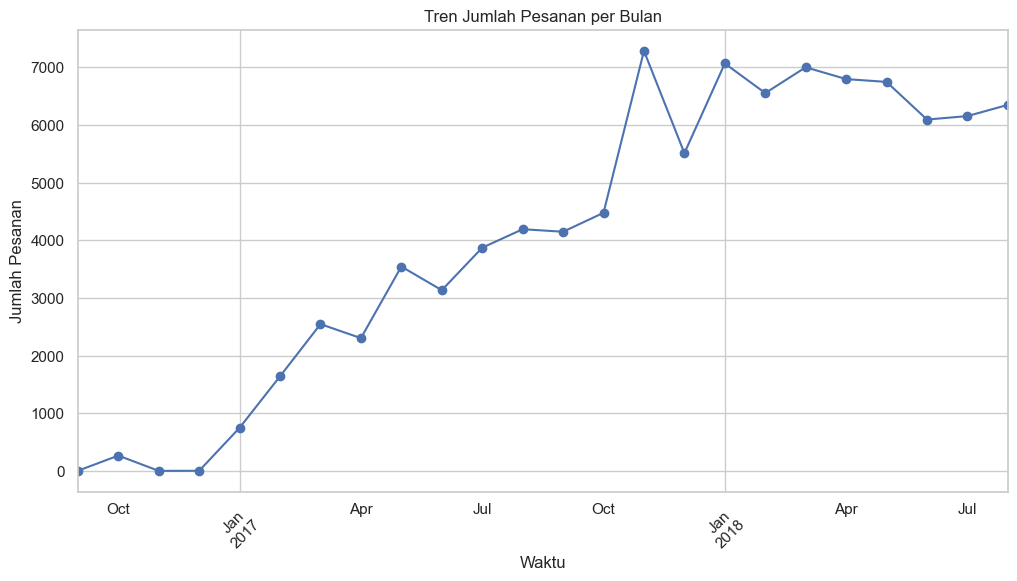

In [116]:
# Menghitung jumlah pesanan per bulan
monthly_orders = all_df.resample(rule='M', on='order_purchase_timestamp')['order_id'].nunique()

# Visualisasi: Tren jumlah pesanan per bulan
plt.figure(figsize=(12, 6))
monthly_orders.plot(marker='o')

plt.title("Tren Jumlah Pesanan per Bulan")
plt.xlabel("Waktu")
plt.ylabel("Jumlah Pesanan")
plt.xticks(rotation=45)
plt.show()

C:\Users\joyce\AppData\Local\Temp\ipykernel_8092\2350049466.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_revenue = all_df.resample(rule='M', on='order_purchase_timestamp')['price'].sum()


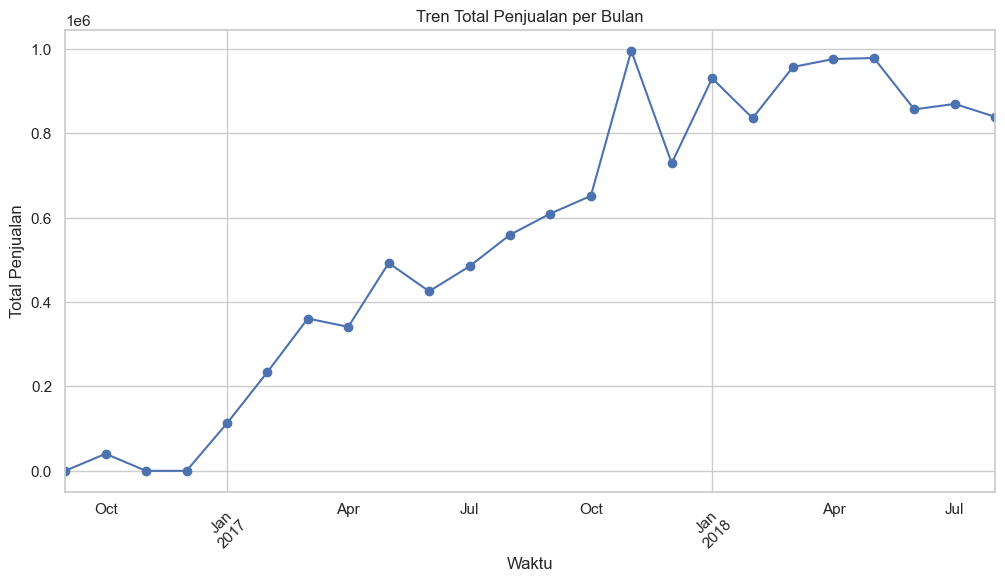

In [117]:
# Menghitung total penjualan per bulan
monthly_revenue = all_df.resample(rule='M', on='order_purchase_timestamp')['price'].sum()

# Visualisasi: Tren total penjualan per bulan
plt.figure(figsize=(12, 6))
monthly_revenue.plot(marker='o')

plt.title("Tren Total Penjualan per Bulan")
plt.xlabel("Waktu")
plt.ylabel("Total Penjualan")
plt.xticks(rotation=45)
plt.show()

**Insight:**
- Kategori cama_mesa_banho merupakan kategori dengan jumlah item terjual terbanyak, sehingga menjadi kategori yang paling sering dibeli oleh pelanggan.
- Penjualan tidak merata antar kategori, di mana beberapa kategori mendominasi dibandingkan kategori lainnya.
- Tren jumlah pesanan menunjukkan peningkatan dari waktu ke waktu hingga mencapai puncak di akhir 2017, kemudian cenderung stabil pada tahun 2018.
- Kenaikan jumlah pesanan sejalan dengan peningkatan total penjualan, yang menunjukkan bahwa pertumbuhan transaksi berkontribusi langsung terhadap revenue.

## Analisis Lanjutan (Opsional)

In [118]:
# Menghitung RFM
rfm_df = all_df.groupby('customer_id', as_index=False).agg({
    'order_purchase_timestamp': 'max',   # terakhir transaksi
    'order_id': 'nunique',               # jumlah order
    'price': 'sum'                       # total belanja
})

rfm_df.columns = ['customer_id', 'last_purchase', 'frequency', 'monetary']

# Hitung recency (selisih hari dari transaksi terakhir)
recent_date = all_df['order_purchase_timestamp'].max()
rfm_df['recency'] = (recent_date - rfm_df['last_purchase']).dt.days

rfm_df.drop('last_purchase', axis=1, inplace=True)

rfm_df.head()

,customer_id,frequency,monetary,recency
0,00012a2ce6f8dcda20d059ce98491703,1,89.80,287
1,000161a058600d5901f007fab4c27140,1,54.90,409
2,0001fd6190edaaf884bcaf3d49edf079,1,179.99,547
3,0002414f95344307404f0ace7a26f1d5,1,149.90,378
4,000379cdec625522490c315e70c7a9fb,1,93.00,149


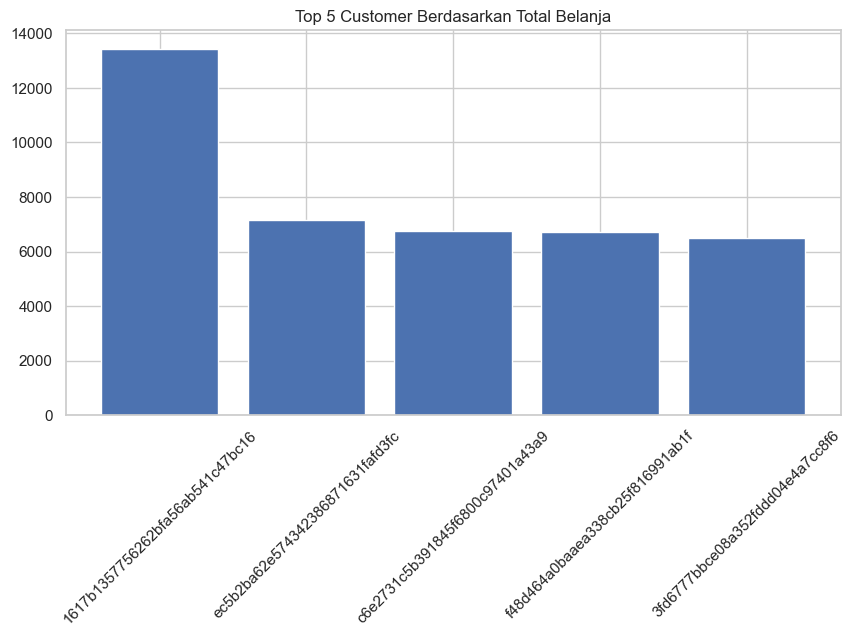

In [119]:
# Top 5 berdasarkan monetary
top_monetary = rfm_df.sort_values(by='monetary', ascending=False).head(5)

plt.figure(figsize=(10,5))
plt.bar(top_monetary['customer_id'], top_monetary['monetary'])
plt.title("Top 5 Customer Berdasarkan Total Belanja")
plt.xticks(rotation=45)
plt.show()

## Conclusion

- Conclution pertanyaan 1: Kategori produk apa yang memberikan kontribusi terbesar terhadap total penjualan, dan bagaimana distribusi penjualan antar kategori? -> Kategori cama_mesa_banho merupakan kategori dengan jumlah item terjual terbanyak, sehingga menjadi kategori yang paling sering dibeli oleh pelanggan. Namun, dari sisi total penjualan, kategori lain seperti beleza_saude memberikan kontribusi yang lebih besar. Secara keseluruhan, distribusi penjualan tidak merata, di mana hanya beberapa kategori yang mendominasi dibandingkan kategori lainnya.
- Conclution pertanyaan 2: Bagaimana tren jumlah pesanan dari waktu ke waktu, dan apakah terdapat pola tertentu dalam periode penjualan? -> Tren jumlah pesanan menunjukkan peningkatan dari waktu ke waktu hingga mencapai puncak pada akhir tahun 2017, kemudian cenderung stabil pada tahun 2018. Pola ini menunjukkan bahwa aktivitas transaksi cenderung meningkat, meskipun pada beberapa periode masih terjadi naik turun yang kemungkinan dipengaruhi oleh waktu atau momen tertentu.